# Problem Statement: Build a Smart Mutual Fund Advisor

*On top of the Mutual Funds Report, [sourced](https://www.kaggle.com/datasets/dhavalrupapara/mutual-funds-market-dataset) from Kaggle*

---

## Objective  
Create a Gradio-based AI assistant that recommends a mutual fund investment portfolio based on the user's risk and return preferences. The app uses Retrieval-Augmented Generation (RAG) on a structured Mutual Fund product dataset, generating explainable, structured results.

---

## User App (Essential Features)

### Inputs
- **Investment Needs**: Free-form text input  
  *(e.g., “high return portfolio, only from Aditya Birla fund house”)*
  
### Output
- **Suggestion**: A natural language explanation of what's recommended and why
- **Recommended Mutual Funds**: Structured as a list containing:
  - Scheme Name
  - Fund House
---

## Developer-Facing Advanced Settings

Shown under a collapsible **LLM Settings (Advanced)** section in the UI.

### Model & Generation Settings
- **Model Selector**: *select 2 more open-source / closed-source models*
  - GPT OSS 120B (`gpt-oss-120b`)
- **Temperature Slider**: Adjustable between 0 and 2

These settings allow developers to tune how deterministic or creative the model’s responses are.

---

## Backend Setup

### Vector Store and RAG
- **Embedding Model**: Nomic Embed Text via Ollama, or other model of your choice
- **Vector Database**: ChromaDB, or other vector DB of your choice
- **RAG Workflow**:
  1. Load product catalog using `CSVLoader`
  2. Parse and clean fields into `Document` objects with metadata
  3. Generate embeddings and index documents
  4. Perform similarity search based on user preferences
  5. Use an LLM to generate structured output parsed via `PydanticOutputParser`

# Part 1: Implement the Solution

## Setup

In [23]:
import gradio as gr
import pandas as pd
import os
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_tavily import TavilySearch
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import CSVLoader
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAI
from langchain.prompts import ChatPromptTemplate
from langchain.output_parsers import PydanticOutputParser
from langchain.schema.output_parser import OutputParserException
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from uuid import uuid4
from langgraph.graph import START, StateGraph, END
from typing_extensions import List, TypedDict
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv

In [24]:
## TODO: Load environment variables and API Keys here
import getpass

load_dotenv(override=True)

#Check for API Keys
api_keys = ["GROQ_API_KEY"]
for api_key in api_keys:
    if api_key not in os.environ:
        os.environ[api_key] = getpass.getpass("Enter the API key: ")

## Defining Components

### Chat Model

In [25]:
## TODO: Model name map for UI Mapping
model_name_map = {
    "GPT-OSS-120B": "openai/gpt-oss-120b",
    ## TODO: Add 2 more models here
    "GPT-OSS-20B": "openai/gpt-oss-20b",
    "QWEN3.8-27B": "qwen/qwen3.8-27b"
}

model_choices = [
    "GPT-OSS-120B (Groq)",
    ## TODO: Add 2 more models here
    "GPT-OSS-20B (Groq)",
    "QWEN3.8-27B (Groq)"
]

In [26]:
## TODO: Model Selector
def get_llm(model_choice, temperature):
    if "Groq" in model_choice:
        return init_chat_model(model_name_map[model_choice.split(" ")[0]], model_provider="groq", temperature = temperature)
    else:
        raise ValueError("Invalid model")

### Embedding Model

In [27]:
## TODO: Create embeddings
## Use: OllamaEmbeddings with llama3.2:1b and pull the model beforehand
!ollama pull nomic-embed-text
embedding_model = OllamaEmbeddings(model="nomic-embed-text")

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest 
pulling 970aa74c0a90: 100% ▕██████████████████▏ 274 MB                         
pulling c71d239df917: 100% ▕██████████████████▏  11 KB                         
pulling ce4a164fc046: 100% ▕██████████████████▏   17 B                         
pulling 31df23ea7daa: 100% ▕██████████████████▏  420 B                         
verifying sha256 digest 
writing manifest 
success 


### Vector Store

In [28]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5"
)

In [29]:
## TODO: Initialize ChromaDB with a persist directory set
from langchain_chroma import Chroma

vectorstore = Chroma(
    collection_name="mutual_funds",
    embedding_function=embeddings_model,
    persist_directory="./chroma_db"
)

## Load and Preprocess Data

In [30]:
# Load and preprocess data
loader = CSVLoader(file_path="mutual_funds_data.csv", source_column="scheme_code")
documents_raw = loader.load()

In [31]:
# Convert page_content string to dict and build metadata
documents = []
for doc in documents_raw:
    try:
        row_data = dict(
            line.split(":", 1) for line in doc.page_content.split("\n") if ":" in line
        )
        row_data = {k.strip(): v.strip() for k, v in row_data.items()}

        ## TODO: Keep Scheme Name, Fund House, Scheme Type, Scheme Category, Net Asset Value and Date in content
        page_text = f"Scheme Name: {row_data.get('scheme_name', '')} | Fund House: {row_data.get('fund_house', '')} | Scheme Type: {row_data.get('scheme_type', '')} | Scheme Category: {row_data.get('scheme_category', '')} | Net Asset Value: {row_data.get('net_asset_value', '')} | Date: {row_data.get('date', '')}"

        ## TODO: Keep Scheme Type, Scheme Category in metadata
        metadata = {
            "scheme_type": row_data.get("scheme_type", ""),
            "scheme_category": row_data.get("scheme_category", "")
        }

        documents.append(Document(page_content=page_text, metadata=metadata))

    except Exception as e:
        print("Skipping row due to error:", e)

In [32]:
len(documents)

35559

In [33]:
print(documents[0].page_content)

Scheme Name: Grindlays Super Saver Income Fund-GSSIF-Half Yearly Dividend | Fund House: Standard Chartered Mutual Fund | Scheme Type: Open Ended Schemes | Scheme Category: Income | Net Asset Value: 10.7205 | Date: 29-05-2008


In [34]:
len(documents)

35559

## Store in Vector DB

In [35]:
## Store in Chroma - 1000 rows only for quicker processing - and make sure to add UUIDs
## TODO: Add UUIDs
uuids = [str(uuid4()) for _ in documents[:1000]]

## TODO: Add documents
documents_to_store = documents[:1000]

vectorstore.add_documents(
    documents=documents_to_store,
    ids=uuids
)

['d9e2d837-564f-4ab2-ae27-7fe43e5c2a56',
 '8cf9d2fa-be9a-4129-887d-833bcdab638c',
 '008efede-afcd-4eee-bb06-b341e18c43a0',
 '94333be8-80bb-46cb-8f94-c5f12053d024',
 '85e8cd2d-3f2f-4bac-884d-0e709b3d271d',
 'e95a3706-d895-4a3b-a458-a54151bd8295',
 'f89c52e2-f727-4ff7-aee5-f66b7813923e',
 '0eba59a3-9ed9-41b7-ab6d-05e1b77d6971',
 'ed7700fb-961b-4b89-a33e-cc1d7cd09a1e',
 '93f7b8d0-2f41-48b9-a5f8-78a6cc89d68f',
 '930e19e6-f604-4d28-82f4-92435cd9fdfc',
 '0ebf914b-ca8b-4097-bbe3-164c11d0cb35',
 '6fdc78b7-0c1c-4659-b447-f5f2cce0210d',
 '3c0089a5-3606-4d8f-a295-937844b97196',
 'cd808201-6169-4642-993b-5d82afef81ee',
 '566942c9-e1ad-44ba-b9d5-aa4633e95e4a',
 'bc3c30f5-bf85-463e-9ede-1959b733c084',
 'ab7eb775-a8b4-4adb-b006-215023979b6b',
 '928daffe-052e-44b7-b1c9-f334c9415b40',
 'd25e0cd9-4422-4066-a42d-3a8fc2acd405',
 '8304b1b8-fdf1-49e4-af96-429d030fcfd6',
 '67b5ecf3-bf02-411d-b195-319431110177',
 'a2be2cf4-f472-49e5-9199-665dbc44c6e1',
 'd80ea304-153d-4a7a-b10b-c273867a7878',
 'e44092a2-1ee9-

## Initializing for RAG

### Initialize Retriever

In [36]:
## TODO: Initializer Retriever below
retriever = vectorstore.as_retriever(search_type="similarity",
                                     search_kwargs={"k": 10})

### Define Pydantic Schema

In [37]:
## TODO: Define Pydantic schema with type and description
class MutualFund(BaseModel):
    scheme_name: str = Field(description="Name of the recommended mutual fund scheme")
    fund_house: str = Field(description="Name of the fund house that offers the scheme")
    scheme_type: str = Field(description="Type of the scheme, for example Open Ended Schemes or Close Ended Schemes")
    scheme_category: str = Field(description="Category of the scheme, for example Income or Growth")
    
class MutualFundOutput(BaseModel):
    reasoning: str = Field(description="Explanation of what is recommended and why, based on the user preferences")
    schemes: list[MutualFund] = Field(description="List of recommended mutual fund schemes")

parser = PydanticOutputParser(pydantic_object=MutualFundOutput)

### Define Prompt

In [38]:
## TODO: Use ChatPromptTemplate.from_template with fields: preferences, context, format_instructions. 
## Make sure no two selected mutual fund schemes fall under the same fund house AND scheme type.

template = ChatPromptTemplate.from_template("""
You are a helpful mutual fund advisor. Based on the user preferences below and the mutual fund catalog context, recommend a portfolio of 3 to 5 mutual fund schemes.
Only recommend schemes that appear in the context below, and copy their details exactly as given.
Make sure no two selected schemes have the same combination of fund house and scheme type.

User Preferences: {preferences}

<context>
{context}
</context>

Return your response as a JSON following this format:
{format_instructions}
""")

## Creating RAG Pipeline

### Test RAG Pipeline Manually

In [39]:
preference = "I want a low risk investment portfolio."
context_docs = retriever.invoke(preference) ## TODO: Retrieve relevant funds
relevant_text = "\n".join([doc.page_content for doc in context_docs]) ## TODO: Joining the funds
llm = get_llm(model_choices[0], 0) ## TODO: Get LLM
chain = template | llm | parser ## TODO: Create a Runnable Sequence with 3 Runnables - template, LLM and Output Parser
input_dict = {
    "preferences": preference,
    "context": relevant_text,
    "format_instructions": parser.get_format_instructions()
} ## TODO: Create dictionary with preferences, context and format_instructions
chain.invoke(input_dict).model_dump() ## TODO: Invoke chain and the output of this command should be a dictionary

{'reasoning': 'The user wants a low‑risk investment portfolio. Both the Principal Short Term Plan‑Dividend and the LIC MF Low Duration Fund‑Regular Plan‑Growth are short‑term, income‑oriented or low‑duration debt schemes, which are typically low‑risk. Because the catalog only contains two distinct combinations of fund house and scheme type (Principal\u202f–\u202fOpen Ended and LIC\u202f–\u202fOpen Ended), we can recommend one scheme from each fund house to avoid duplicate fund‑house/type pairs. This yields the best low‑risk options available in the provided list.',
 'schemes': [{'scheme_name': 'Principal Short Term Plan-Dividend',
   'fund_house': 'PRINCIPAL Mutual Fund',
   'scheme_type': 'Open Ended Schemes',
   'scheme_category': 'Income'},
  {'scheme_name': 'LIC MF Low Duration Fund-Regular Plan-Growth',
   'fund_house': 'LIC Mutual Fund',
   'scheme_type': 'Open Ended Schemes',
   'scheme_category': 'Debt Scheme - Low Duration Fund'}]}

### Define RAG Pipeline Function

In [40]:
# RAG pipeline
def generate_portfolio(model_choice, user_input):
    context_docs = retriever.invoke(user_input["preferences"]) ## TODO: Retrieving relevant funds
    relevant_funds = "\n".join([doc.page_content for doc in context_docs]) ## TODO: Joining the funds
    llm = get_llm(user_input["model_choice"], user_input["temperature"]) ## TODO: Get the LLM
    
    #Invoking
    chain = template | llm ## TODO: Create a Runnable Sequence with 2 Runnables - template and LLM
    output = chain.invoke({
        "preferences": user_input["preferences"],
        "context": relevant_funds,
        "format_instructions": parser.get_format_instructions()
    }) ## TODO: Invoke the Runnable Sequence with the preferences, context and format instructions

    #Exception Handling
    try:
        result = parser.parse(output.content)
    except OutputParserException:
        return "Could not parse output.", None
    return result

## User Interface

In [41]:
def gradio_interface(preferences, model_choice, temperature):
    user_input = {
        "preferences": preferences,
        "model_choice": model_choice,
        "temperature": temperature,
    }
    result = generate_portfolio(model_choice, user_input)
    if not result or isinstance(result, str):
        return result, []
    if isinstance(result, tuple):
        explanation, _ = result
        return explanation, []
    # Build a plain text list of scheme recommendations
    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [42]:
# Gradio Blocks layout
with gr.Blocks(title="Smart Mutual Fund Advisor") as demo:
    gr.Markdown("## Smart Mutual Fund Advisor")
    gr.Markdown("Enter your investment preferences and let AI suggest a portfolio!")

    with gr.Row():
        preferences_input = gr.Textbox(
            label="Describe your investment needs",
            placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
            lines=2
        )

    with gr.Accordion("LLM Settings (Advanced)", open=False):
        model_dropdown = gr.Dropdown(
            label="Model",
            choices=model_choices,
            value=model_choices[0]
        )
        temperature_slider = gr.Slider(
            minimum=0.0, maximum=2, value=0.7, step=0.1,
            label="Temperature"
        )

    run_button = gr.Button("Generate Portfolio")

    with gr.Row():
        reasoning_output = gr.Textbox(label="Remarks", lines=2)

    with gr.Row():
        fund_list_output = gr.Textbox(label="Recommended Mutual Funds", lines=10)

    run_button.click(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output]
    )

In [43]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


# Part 2: Implement the RAG pipeline in LangGraph

## Creating Graph

### Define State Class

In [44]:
## TODO: Define State class with preferences, context and answer keys
class State(TypedDict):
    preferences: str
    context: List[Document]
    answer: str

### Define Nodes

In [45]:
## TODO: Define retrieve node
def retrieve(state: State):
    relevant_funds = retriever.invoke(state["preferences"]) ## TODO: Retrieving relevant mutual funds
    return {"context": relevant_funds} ## TODO: Return the relevant parts of the state: context only

In [46]:
## TODO: Define generate node
def generate(state: State):
    relevant_funds_str = "\n".join([doc.page_content for doc in state["context"]]) ## TODO: Joining the mutual funds
        
    chain = template | llm_graph ## TODO: Create a Runnable Sequence with 2 Runnables - template and llm_graph (different variable that's defined later)
    output = chain.invoke({
        "preferences": state["preferences"],
        "context": relevant_funds_str,
        "format_instructions": parser.get_format_instructions()
    }) ## TODO: Invoke the Runnable Sequence with the preferences, context and format instructions

    #Exception Handling for Output Parser
    try:
        result = parser.parse(output.content)
    except OutputParserException:
        return "Could not parse output.", None
        
    return {"answer": result} ## TODO: Return the relevant parts of the state: answer only

### Build and Compile Graph

In [47]:
## TODO: Build the graph with 2 nodes and 3 edges
graph_builder = StateGraph(State) ## TODO: To add

graph_builder.add_node("retrieve", retrieve) ## TODO: To add
graph_builder.add_node("generate", generate) ## TODO: To add

graph_builder.add_edge(START, "retrieve") ## TODO: To add
graph_builder.add_edge("retrieve", "generate") ## TODO: To add
graph_builder.add_edge("generate", END) ## TODO: To add

In [48]:
#Compile graph
graph = graph_builder.compile()

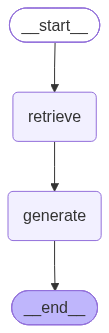

In [49]:
#Visualize graph
display(Image(graph.get_graph().draw_mermaid_png()))

### Test Manually

In [50]:
preferences = "I want a low risk investment portfolio."
llm_graph = get_llm(model_choices[0], 0) ## TODO: Get LLM
result = graph.invoke({"preferences": preferences}) ## TODO: Invoke the graph
print(f'Context: {result["context"]}\n\n')
print(f'Answer: {result["answer"]}')

Context: [Document(id='bffa837c-c7ac-4d38-8ff6-885547c2e533', metadata={'scheme_type': 'Open Ended Schemes', 'scheme_category': 'Income'}, page_content='Scheme Name: Principal Short Term Plan-Dividend | Fund House: PRINCIPAL Mutual Fund | Scheme Type: Open Ended Schemes | Scheme Category: Income | Net Asset Value: 10.7162 | Date: 23-09-2010'), Document(id='d1a4c379-83fa-4580-bfc1-92acb0592977', metadata={'scheme_category': 'Income', 'scheme_type': 'Open Ended Schemes'}, page_content='Scheme Name: Principal Short Term Plan-Dividend | Fund House: PRINCIPAL Mutual Fund | Scheme Type: Open Ended Schemes | Scheme Category: Income | Net Asset Value: 10.7162 | Date: 23-09-2010'), Document(id='e51b1582-1b5a-4509-ba3e-0b46671f79c2', metadata={'scheme_category': 'Debt Scheme - Low Duration Fund', 'scheme_type': 'Open Ended Schemes'}, page_content='Scheme Name: LIC MF Low Duration Fund-Regular Plan-Growth\nFund House: LIC Mutual Fund\nScheme Type: Open Ended Schemes\nScheme Category: Debt Scheme 

## User Interface

In [51]:
def gradio_interface(preferences, model_choice, temperature):
    user_input = {
        "preferences": preferences,
        "model_choice": model_choice,
        "temperature": temperature,
    }
    llm_graph = get_llm(user_input["model_choice"], user_input["temperature"])
    result = graph.invoke({"preferences": preferences})["answer"]
    
    if not result or isinstance(result, str):
        return result, []
    if isinstance(result, tuple):
        explanation, _ = result
        return explanation, []
    # Build a plain text list of scheme recommendations
    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [52]:
# Gradio Blocks layout
with gr.Blocks(title="Smart Mutual Fund Advisor") as demo:
    gr.Markdown("## Smart Mutual Fund Advisor")
    gr.Markdown("Enter your investment preferences and let AI suggest a portfolio!")

    with gr.Row():
        preferences_input = gr.Textbox(
            label="Describe your investment needs",
            placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
            lines=2
        )

    with gr.Accordion("LLM Settings (Advanced)", open=False):
        model_dropdown = gr.Dropdown(
            label="Model",
            choices=model_choices,
            value=model_choices[0]
        )
        temperature_slider = gr.Slider(
            minimum=0.0, maximum=2, value=0.7, step=0.1,
            label="Temperature"
        )

    run_button = gr.Button("Generate Portfolio")

    with gr.Row():
        reasoning_output = gr.Textbox(label="Remarks", lines=2)

    with gr.Row():
        fund_list_output = gr.Textbox(label="Recommended Mutual Funds", lines=10)

    run_button.click(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output]
    )

In [53]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.
